# FeatureMAP on synthetic data with linear model.

In [1]:
import featuremap

import warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=DeprecationWarning)

/Users/uqyyao4/opt/anaconda3/envs/featmap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [100]:
# Synthesize a dataset with Gaussian blobs
import numpy as np

from sklearn.datasets import make_blobs

n_time_points =3

per_samples = 1000
n_samples = per_samples * n_time_points
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]
centers = np.array([[-1, 0], [0, 0], [1, 0]])*5

X, y = make_blobs(n_samples=n_samples, centers=centers , random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples,  centers=centers,  cluster_std=[0.5, 1.0, 2.5], random_state=random_state
)  # Unequal variance
ratio_1 = 0.5
ratio_2 = 0.1
X_filtered = np.vstack(
    (X[y == 0][:per_samples], X[y == 1][:int(per_samples*ratio_1)], X[y == 2][:int(per_samples*ratio_2)])
)  # Unevenly sized blobs
y_filtered = [0] * per_samples + [1] *int(per_samples*ratio_1) + [2] * int(per_samples*ratio_2)


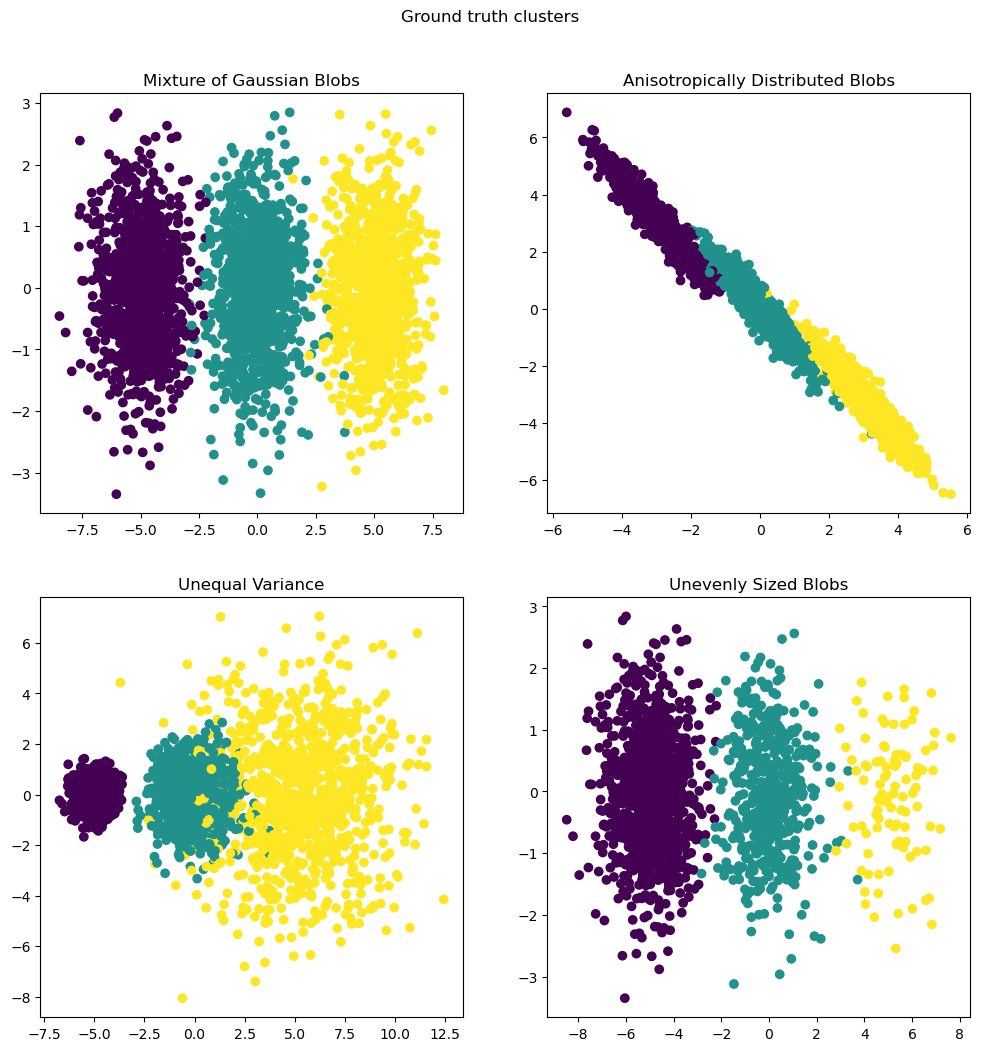

In [101]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

[[0. 1.]
 [2. 3.]
 [4. 5.]]


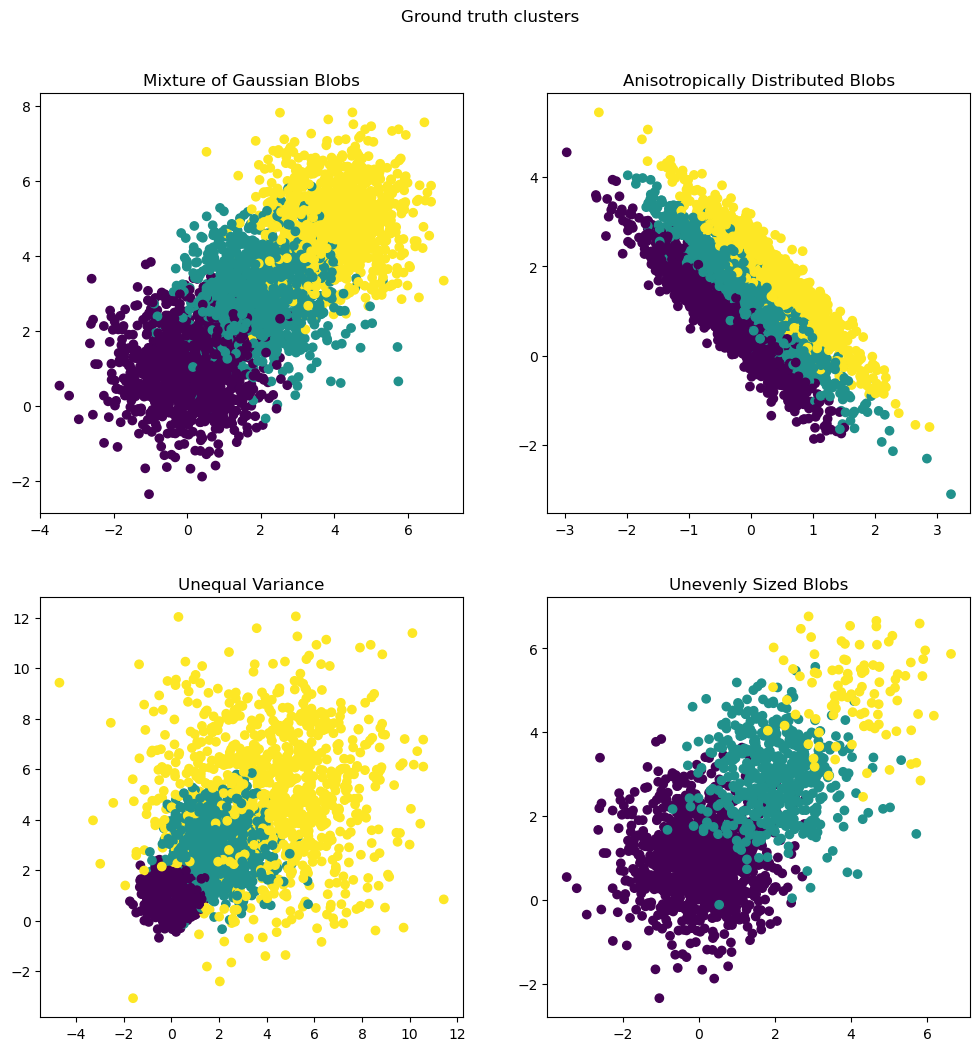

In [107]:
# Synthesize a dataset with Gaussian blobs
import numpy as np

from sklearn.datasets import make_blobs

n_time_points =3
n_features = 2

per_samples = 1000
n_samples = per_samples * n_time_points
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

# Define centers for the blobs in a line
centers = np.zeros((n_time_points, n_features))
for i in range(n_time_points):
    centers[i] = np.arange(n_features) + i*2
print(centers)

X, y = make_blobs(n_samples=n_samples, centers=centers , random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples,  centers=centers,  cluster_std=[0.5, 1.0, 2.5], random_state=random_state
)  # Unequal variance
ratio_1 = 0.5
ratio_2 = 0.1
X_filtered = np.vstack(
    (X[y == 0][:per_samples], X[y == 1][:int(per_samples*ratio_1)], X[y == 2][:int(per_samples*ratio_2)])
)  # Unevenly sized blobs
y_filtered = [0] * per_samples + [1] *int(per_samples*ratio_1) + [2] * int(per_samples*ratio_2)

import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()


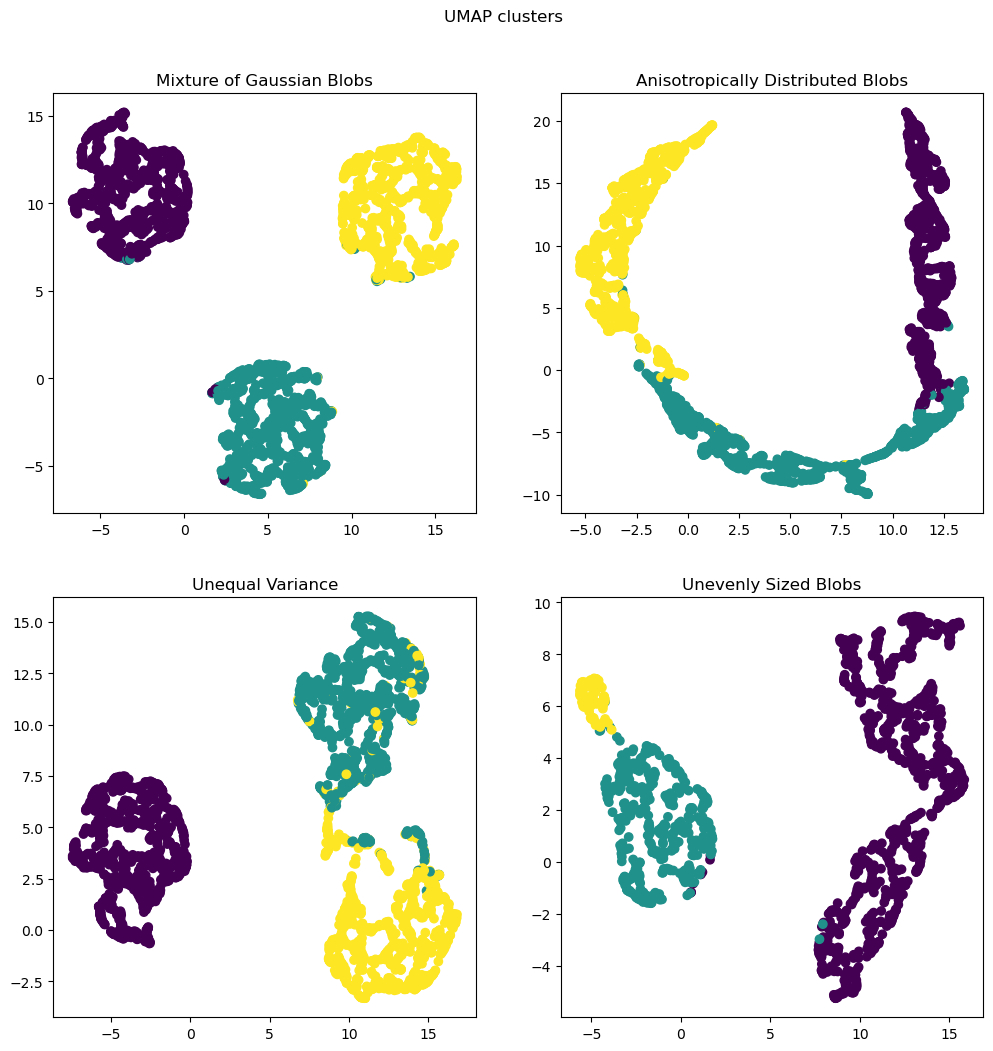

In [102]:
import umap

# Fit UMAP to the data
umap_ = umap.UMAP()
X_umap = umap_.fit_transform(X)
# plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y)
# plt.title("Mixture of Gaussian Blobs")
# plt.show()

umap_aniso = umap.UMAP()
X_aniso_umap = umap_aniso.fit_transform(X_aniso)
# plt.scatter(X_aniso_umap[:, 0], X_aniso_umap[:, 1], c=y)
# plt.title("Anisotropically Distributed Blobs")
# plt.show()

umap_varied = umap.UMAP()
X_varied_umap = umap_varied.fit_transform(X_varied)
# plt.scatter(X_varied_umap[:, 0], X_varied_umap[:, 1], c=y_varied)
# plt.title("Unequal Variance")
# plt.show()


umap_filtered = umap.UMAP()
X_filtered_umap = umap_filtered.fit_transform(X_filtered)
# plt.scatter(X_filtered_umap[:, 0], X_filtered_umap[:, 1], c=y_filtered)
# plt.title("Unevenly Sized Blobs")
# plt.show()


fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))
axs[0, 0].scatter(X_umap[:, 0], X_umap[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso_umap[:, 0], X_aniso_umap[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied_umap[:, 0], X_varied_umap[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered_umap[:, 0], X_filtered_umap[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("UMAP clusters").set_y(0.95)
plt.show()


[[ 0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19. ]
 [ 0.1  1.1  2.1  3.1  4.1  5.1  6.1  7.1  8.1  9.1 10.1 11.1 12.1 13.1
  14.1 15.1 16.1 17.1 18.1 19.1]
 [ 0.2  1.2  2.2  3.2  4.2  5.2  6.2  7.2  8.2  9.2 10.2 11.2 12.2 13.2
  14.2 15.2 16.2 17.2 18.2 19.2]]


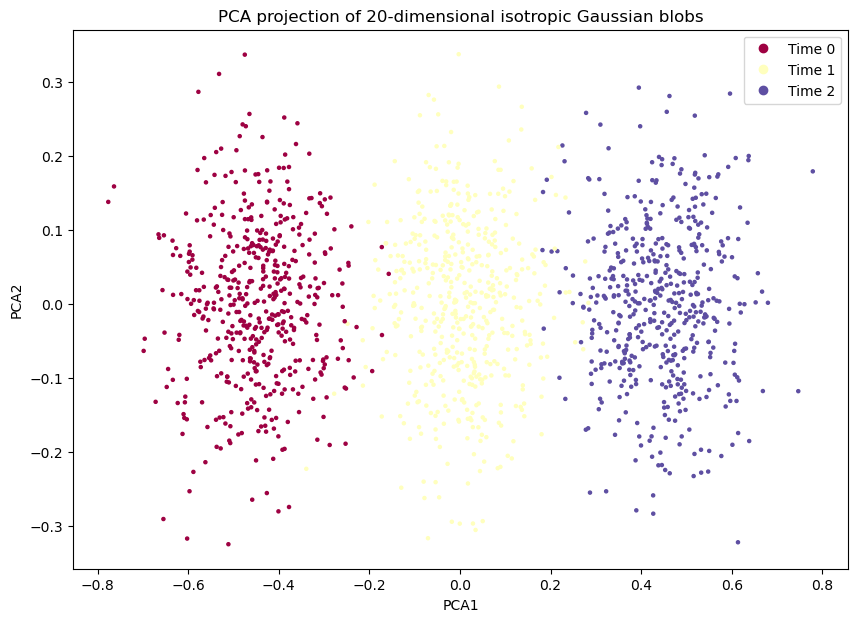

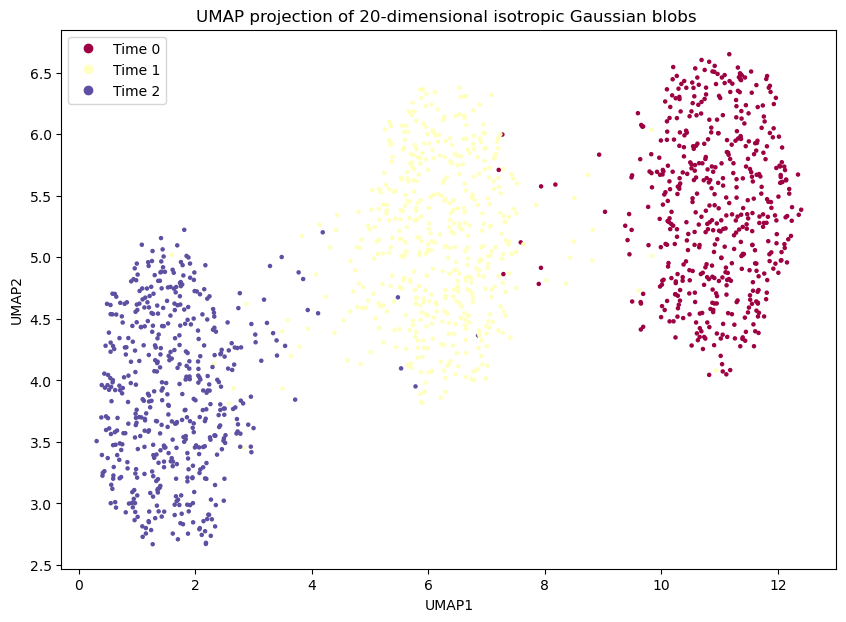

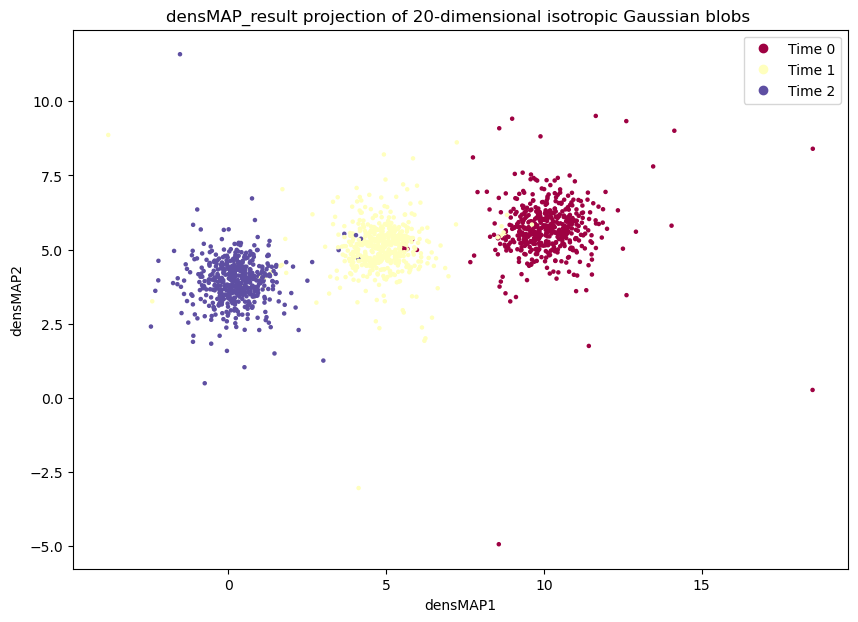

/Users/uqyyao4/opt/anaconda3/envs/featmap/lib/python3.9/site-packages/numba/core/decorators.py:250: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


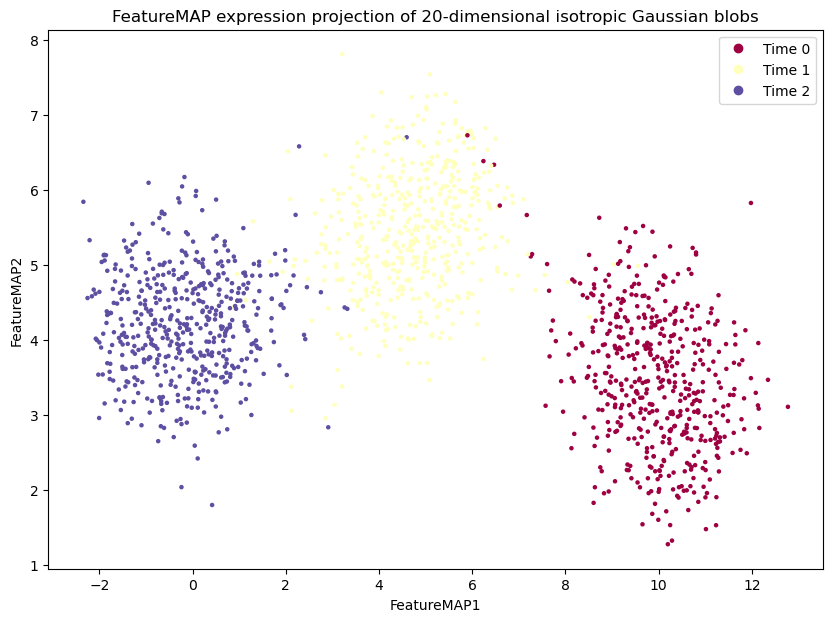

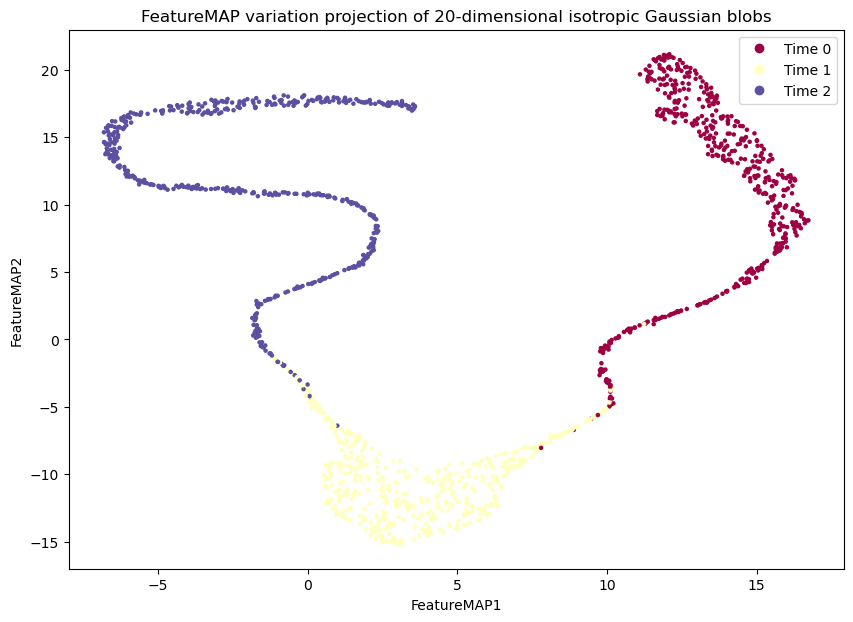

In [116]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

n_time_points = 3
n_features = 20
n_samples = 500 * n_time_points

# Define centers for the blobs in a line
centers = np.zeros((n_time_points, n_features))
for i in range(n_time_points):
    centers[i] = np.arange(n_features) + i*0.1

print(centers)

# Generate 20-dimensional isotropic Gaussian blobs for clustering
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=centers, cluster_std=0.1, random_state=42)

# Apply PCA to reduce dimensionality to 2 dimensions for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Plot the PCA result
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y, s=5, cmap='Spectral')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
plt.title('PCA projection of 20-dimensional isotropic Gaussian blobs')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

# UMAP plot
umap_result = umap.UMAP().fit_transform(X)

# Plot the UMAP result
plt.figure(figsize=(10, 7))
scatter = plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y, s=5, cmap='Spectral')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
plt.title('UMAP projection of 20-dimensional isotropic Gaussian blobs ')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

# densMAP plot
densmap_result = umap.UMAP(densmap=True).fit_transform(X)

# Plot the UMAP result
plt.figure(figsize=(10, 7))
scatter = plt.scatter(densmap_result[:, 0], densmap_result[:, 1], c=y, s=5, cmap='Spectral')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
plt.title('densMAP_result projection of 20-dimensional isotropic Gaussian blobs ')
plt.xlabel('densMAP1')
plt.ylabel('densMAP2')
plt.show()

# featuremap expr plot
emb_featuremap_expr = featuremap.FeatureMAP(
                    random_state=42,
                    # output_variation=True,
                    feat_gauge_coefficient=1,
                    n_epochs=400,
                    ).fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(emb_featuremap_expr[:, 0], emb_featuremap_expr[:, 1], c=y, s=5, cmap='Spectral')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
plt.title('FeatureMAP expression projection of 20-dimensional isotropic Gaussian blobs')
plt.xlabel('FeatureMAP1')
plt.ylabel('FeatureMAP2')
plt.show()




# featuremap var plot
emb_featuremap_var = featuremap.FeatureMAP(
                    random_state=42,
                    output_variation=True,
                    feat_gauge_coefficient=1,
                    n_epochs=400,
                    ).fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(emb_featuremap_var[:, 0], emb_featuremap_var[:, 1], c=y, s=5, cmap='Spectral')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
plt.title('FeatureMAP variation projection of 20-dimensional isotropic Gaussian blobs')
plt.xlabel('FeatureMAP1')
plt.ylabel('FeatureMAP2')
plt.show()

# fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 12))

# axs[0, 0].scatter(pca_result[:, 0], pca_result[:, 1], c=y, s=5, cmap='Spectral')
# axs[0, 0].set_title("PCA")

# axs[0, 1].scatter(umap_result[:, 0], umap_result[:, 1], c=y, s=5, cmap='Spectral')
# axs[0, 1].set_title("UMAP")

# axs[0, 2].scatter(densmap_result[:, 0], densmap_result[:, 1], c=y, s=5, cmap='Spectral')
# axs[0, 2].set_title("densMAP")

# axs[1, 0].scatter(emb_featuremap_expr[:, 0], emb_featuremap_expr[:, 1], c=y, s=5, cmap='Spectral')
# axs[1, 0].set_title("FeatureMAP expression")

# axs[1, 1].scatter(emb_featuremap_var[:, 0], emb_featuremap_var[:, 1], c=y, s=5, cmap='Spectral')
# axs[1, 1].set_title("FeatureMAP variation")



[[ 0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19. ]
 [ 0.1  1.1  2.1  3.1  4.1  5.1  6.1  7.1  8.1  9.1 10.1 11.1 12.1 13.1
  14.1 15.1 16.1 17.1 18.1 19.1]
 [ 0.2  1.2  2.2  3.2  4.2  5.2  6.2  7.2  8.2  9.2 10.2 11.2 12.2 13.2
  14.2 15.2 16.2 17.2 18.2 19.2]]


/Users/uqyyao4/opt/anaconda3/envs/featmap/lib/python3.9/site-packages/numba/core/decorators.py:250: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


Text(0.5, 1.0, 'Projection of 20-dimensional isotropic Gaussian unevenly sized blobs')

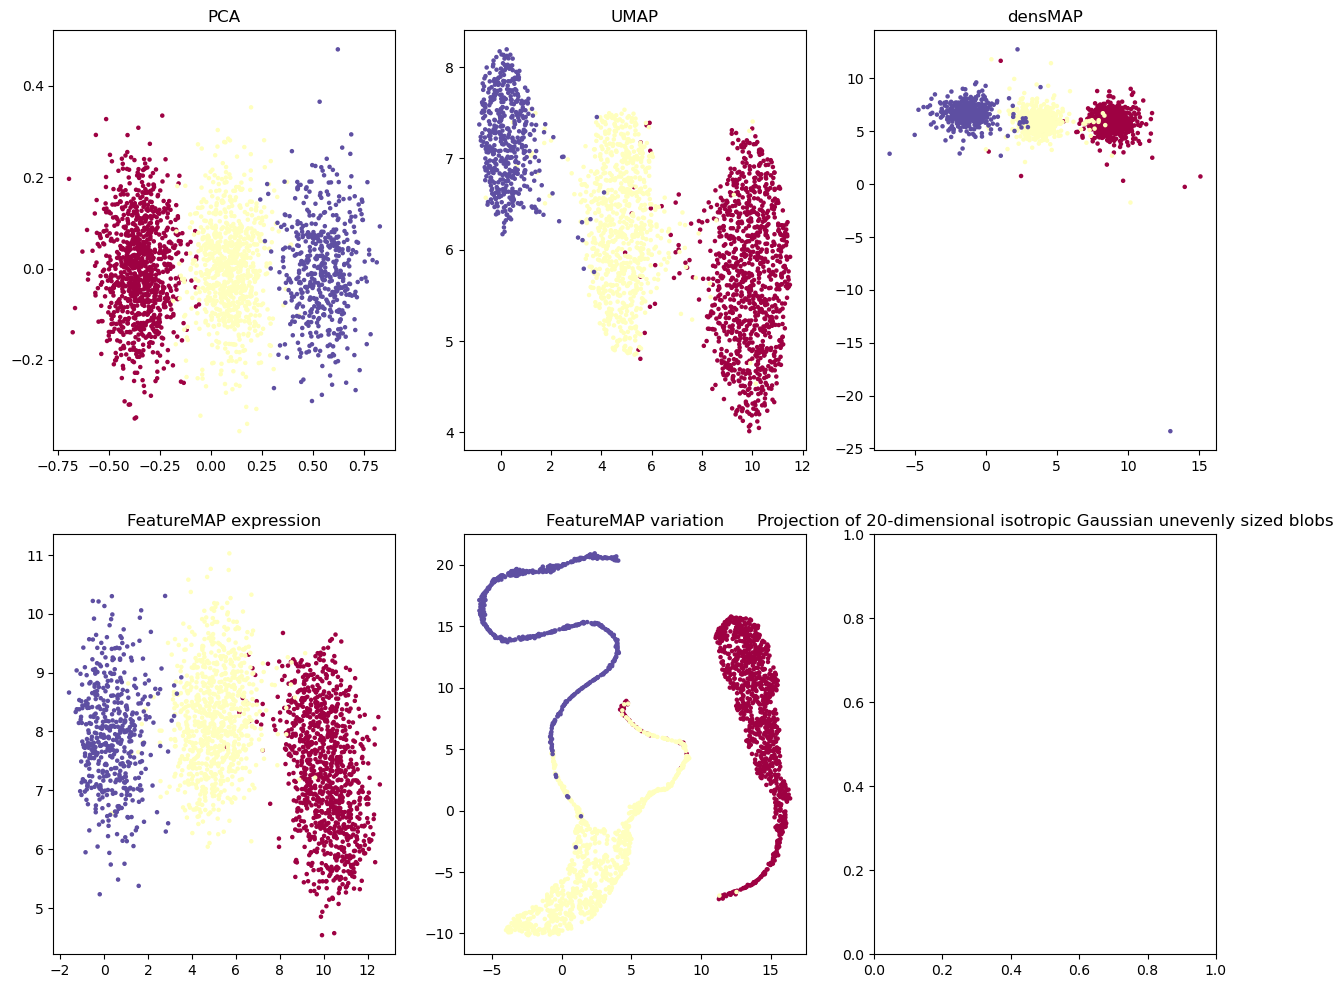

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

n_time_points = 3
n_features = 20
per_samples = 1000 
n_samples = per_samples * n_time_points

# Define centers for the blobs in a line
centers = np.zeros((n_time_points, n_features))
for i in range(n_time_points):
    centers[i] = np.arange(n_features) + i*0.1

print(centers)

# Generate 20-dimensional isotropic Gaussian blobs for clustering
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=centers, cluster_std=0.1, random_state=42)

# Downsample the data to create unevenly sized blobs
ratio_1 = 0.8
ratio_2 = 0.5
X_filtered = np.vstack(
    (X[y == 0][:per_samples], X[y == 1][:int(per_samples*ratio_1)], X[y == 2][:int(per_samples*ratio_2)])
)  # Unevenly sized blobs
y_filtered = [0] * per_samples + [1] * int(per_samples*ratio_1) + [2] * int(per_samples*ratio_2)

# Apply PCA to reduce dimensionality to 2 dimensions for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_filtered)

# # Plot the PCA result
# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('PCA projection of 20-dimensional isotropic Gaussian unevenly sized blobs')
# plt.xlabel('PCA1')
# plt.ylabel('PCA2')
# plt.show()

# UMAP plot
umap_result = umap.UMAP().fit_transform(X_filtered)

# # Plot the UMAP result
# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('UMAP projection of 20-dimensional isotropic Gaussian unevenly sized blobs ')
# plt.xlabel('UMAP1')
# plt.ylabel('UMAP2')
# plt.show()

# densMAP plot
densmap_result = umap.UMAP(densmap=True).fit_transform(X_filtered)

# # Plot the densMAP result
# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(densmap_result[:, 0], densmap_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('densMAP_result projection of 20-dimensional isotropic Gaussian unevenly sized blobs ')
# plt.xlabel('densMAP1')
# plt.ylabel('densMAP2')
# plt.show()



# featuremap plot
emb_featuremap_expr = featuremap.FeatureMAP(
                    random_state=42,
                    # output_variation=True,
                    feat_gauge_coefficient=1,
                    # n_epochs=400,
                    ).fit_transform(X_filtered)

# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(emb_featuremap_expr[:, 0], emb_featuremap_expr[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('FeatureMAP projection of 20-dimensional isotropic Gaussian unevenly sized blobs')
# plt.xlabel('FeatureMAP1')
# plt.ylabel('FeatureMAP2')
# plt.show()



# featuremap plot
emb_featuremap_var = featuremap.FeatureMAP(
                    random_state=42,
                    output_variation=True,
                    feat_gauge_coefficient=1,
                    # n_epochs=400,
                    ).fit_transform(X_filtered)

# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(emb_featuremap_var[:, 0], emb_featuremap_var[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('FeatureMAP projection of 20-dimensional isotropic Gaussian unevenly sized blobs')
# plt.xlabel('FeatureMAP1')
# plt.ylabel('FeatureMAP2')
# plt.show()


fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 12))

axs[0, 0].scatter(pca_result[:, 0], pca_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
axs[0, 0].set_title("PCA")

axs[0, 1].scatter(umap_result[:, 0], umap_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
axs[0, 1].set_title("UMAP")

axs[0, 2].scatter(densmap_result[:, 0], densmap_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
axs[0, 2].set_title("densMAP")

axs[1, 0].scatter(emb_featuremap_expr[:, 0], emb_featuremap_expr[:, 1], c=y_filtered, s=5, cmap='Spectral')
axs[1, 0].set_title("FeatureMAP expression")

axs[1, 1].scatter(emb_featuremap_var[:, 0], emb_featuremap_var[:, 1], c=y_filtered, s=5, cmap='Spectral')
axs[1, 1].set_title("FeatureMAP variation")


plt.suptitle('Projection of 20-dimensional isotropic Gaussian unevenly sized blobs').set_y(0.95)
plt.show()



In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA

n_time_points = 3
n_features = 20
per_samples = 1000 
n_samples = per_samples * n_time_points

# Define centers for the blobs in a line
centers = np.zeros((n_time_points, n_features))
for i in range(n_time_points):
    centers[i] = np.arange(n_features) + i*0.1

print(centers)

# Unequal variance
cluster_std = [0.1*(2*i+1) for i in range(n_time_points)]
print(cluster_std)
# Generate 20-dimensional isotropic Gaussian blobs for clustering
X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=centers, cluster_std=cluster_std, random_state=42)

# # Downsample the data to create unevenly sized blobs
# ratio_1 = 0.8
# ratio_2 = 0.5
# X_filtered = np.vstack(
#     (X[y == 0][:per_samples], X[y == 1][:int(per_samples*ratio_1)], X[y == 2][:int(per_samples*ratio_2)])
# )  # Unevenly sized blobs
# y_filtered = [0] * per_samples + [1] * int(per_samples*ratio_1) + [2] * int(per_samples*ratio_2)

# Apply PCA to reduce dimensionality to 2 dimensions for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# # Plot the PCA result
# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('PCA projection of 20-dimensional isotropic Gaussian unevenly sized blobs')
# plt.xlabel('PCA1')
# plt.ylabel('PCA2')
# plt.show()

# UMAP plot
umap_result = umap.UMAP().fit_transform(X)

# # Plot the UMAP result
# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(umap_result[:, 0], umap_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('UMAP projection of 20-dimensional isotropic Gaussian unevenly sized blobs ')
# plt.xlabel('UMAP1')
# plt.ylabel('UMAP2')
# plt.show()

# densMAP plot
densmap_result = umap.UMAP(densmap=True).fit_transform(X)

# # Plot the densMAP result
# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(densmap_result[:, 0], densmap_result[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('densMAP_result projection of 20-dimensional isotropic Gaussian unevenly sized blobs ')
# plt.xlabel('densMAP1')
# plt.ylabel('densMAP2')
# plt.show()



# featuremap plot
emb_featuremap_expr = featuremap.FeatureMAP(
                    random_state=42,
                    # output_variation=True,
                    feat_gauge_coefficient=2,
                    # n_epochs=400,
                    ).fit_transform(X)

# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(emb_featuremap_expr[:, 0], emb_featuremap_expr[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('FeatureMAP projection of 20-dimensional isotropic Gaussian unevenly sized blobs')
# plt.xlabel('FeatureMAP1')
# plt.ylabel('FeatureMAP2')
# plt.show()



# featuremap plot
emb_featuremap_var = featuremap.FeatureMAP(
                    random_state=42,
                    output_variation=True,
                    feat_gauge_coefficient=2,
                    n_epochs=400,
                    ).fit_transform(X)

# plt.figure(figsize=(10, 7))
# scatter = plt.scatter(emb_featuremap_var[:, 0], emb_featuremap_var[:, 1], c=y_filtered, s=5, cmap='Spectral')
# plt.legend(handles=scatter.legend_elements()[0], labels=[f'Time {i}' for i in range(n_time_points)])
# plt.title('FeatureMAP projection of 20-dimensional isotropic Gaussian unevenly sized blobs')
# plt.xlabel('FeatureMAP1')
# plt.ylabel('FeatureMAP2')
# plt.show()


fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 12))

axs[0, 0].scatter(pca_result[:, 0], pca_result[:, 1], c=y, s=5, cmap='Spectral')
axs[0, 0].set_title("PCA")

axs[0, 1].scatter(umap_result[:, 0], umap_result[:, 1], c=y, s=5, cmap='Spectral')
axs[0, 1].set_title("UMAP")

axs[0, 2].scatter(densmap_result[:, 0], densmap_result[:, 1], c=y, s=5, cmap='Spectral')
axs[0, 2].set_title("densMAP")

axs[1, 0].scatter(emb_featuremap_expr[:, 0], emb_featuremap_expr[:, 1], c=y, s=5, cmap='Spectral')
axs[1, 0].set_title("FeatureMAP expression")

axs[1, 1].scatter(emb_featuremap_var[:, 0], emb_featuremap_var[:, 1], c=y, s=5, cmap='Spectral')
axs[1, 1].set_title("FeatureMAP variation")

plt.title('Projection of 20-dimensional isotropic Gaussian unevenly sized blobs')


[[ 0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19. ]
 [ 0.1  1.1  2.1  3.1  4.1  5.1  6.1  7.1  8.1  9.1 10.1 11.1 12.1 13.1
  14.1 15.1 16.1 17.1 18.1 19.1]
 [ 0.2  1.2  2.2  3.2  4.2  5.2  6.2  7.2  8.2  9.2 10.2 11.2 12.2 13.2
  14.2 15.2 16.2 17.2 18.2 19.2]]
[0.1, 0.30000000000000004, 0.5]


/Users/uqyyao4/opt/anaconda3/envs/featmap/lib/python3.9/site-packages/numba/core/decorators.py:250: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [83]:
cluster_std

[0.1, 0.6000000000000001, 1.1]